In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [3]:
from keras import backend as K
print(K.backend())

tensorflow


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


x_train = x_train.reshape(60000, 784).astype("float32") / 255.0 # skaalaa 28x28 kuvan yhdeksi vektoriksi pituudella 28*28 = 784
x_test = x_test.reshape(10000, 784).astype("float32") / 255.0 # tekee saman skaalauksen testijoukolle

<class 'numpy.ndarray'>


In [6]:
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

In [7]:
# plt.imshow(x_train[1001], cmap="gray")

In [8]:
inputs = keras.Input(shape=(784,))
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model") # Valmis neuroverkko kolmella layerillä (32, 16 ja output layer 10, mikä on One-Hot)
model.summary()

Model: "mnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["Accuracy"]
)

In [10]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.8536 - loss: 0.5059 - val_Accuracy: 0.9318 - val_loss: 0.2415
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9375 - loss: 0.2208 - val_Accuracy: 0.9463 - val_loss: 0.1896
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9496 - loss: 0.1753 - val_Accuracy: 0.9545 - val_loss: 0.1634
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9585 - loss: 0.1484 - val_Accuracy: 0.9580 - val_loss: 0.1475
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9614 - loss: 0.1293 - val_Accuracy: 0.9586 - val_loss: 0.1437
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9665 - loss: 0.1145 - val_Accuracy: 0.9630 - val_loss: 0.1314
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9694 - loss: 0.1036 - val_Accuracy: 0.9629 - val_loss: 0.1307
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9726 - loss: 0.0948 - val_Accuracy: 0.

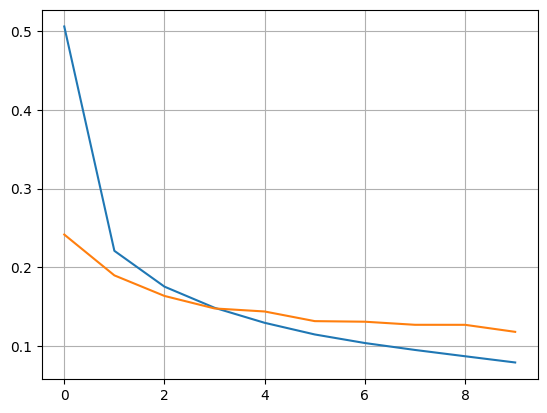

In [11]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [12]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 0s - 1ms/step - Accuracy: 0.9625 - loss: 0.1252
Test loss: 0.12523770332336426
Test accuracy: 0.9624999761581421


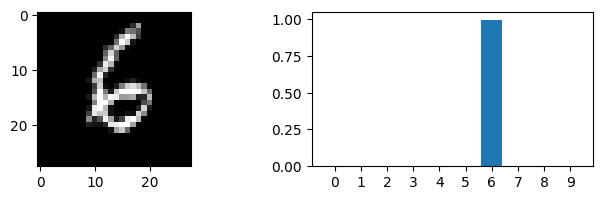

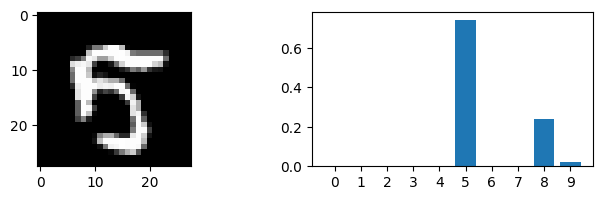

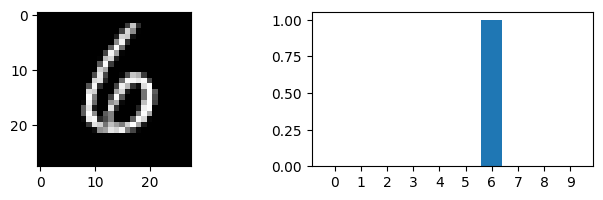

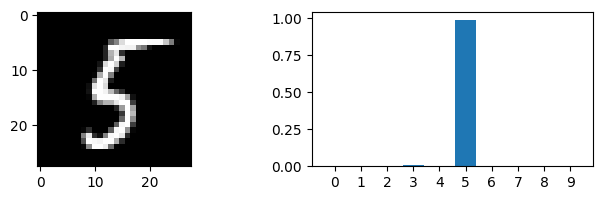

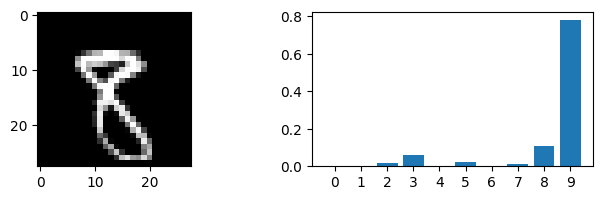

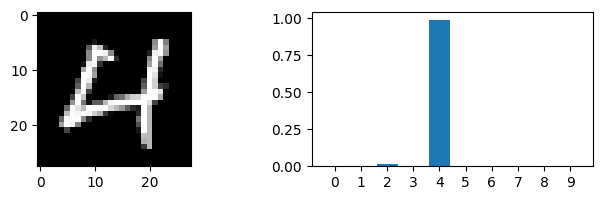

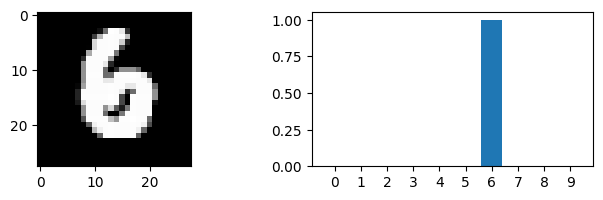

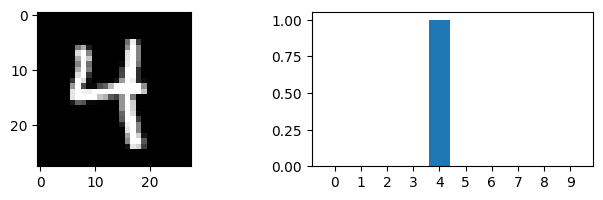

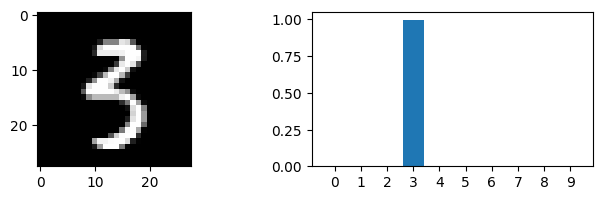

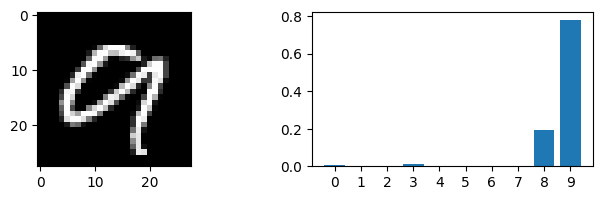

In [13]:
x = x_test
y = model(x)
start = 2000

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k].reshape((28, 28)), cmap='gray')
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, y[start+k].numpy().flatten())
    plt.xticks(range(10))